# Double DQN Trading Strategy

In this case study, we implement a **Double Deep Q-Network (Double DQN)** based trading strategy.

## Key Difference from Standard DQN
Double DQN addresses the overestimation bias in standard DQN by:
1. Using the **online network** to select the best action for the next state
2. Using the **target network** to evaluate the Q-value of that action

This decoupling reduces overestimation and leads to more stable training. 


## Content

* [1. Problem Definition](#0)
* [2. Getting Started - Load Libraries and Dataset](#1)
    * [2.1. Load Libraries](#1.1)    
    * [2.2. Load Dataset](#1.2)
* [3. Exploratory Data Analysis](#2)
    * [3.1 Descriptive Statistics](#2.1)    
    * [3.2. Data Visualisation](#2.2)
* [4. Data Preparation](#3)
    * [4.1 Data Cleaning](#3.1) 
* [5.Evaluate Algorithms and Models](#5) 
    * [5.1. Train Test Split](#5.1)
    * [5.2. Implementation steps and modules](#5.2)
    * [5.3. Agent Script](#5.3)
    * [5.4. Helper Function](#5.4)
    * [5.5. Training Set](#5.5)       

* [6.Test Set](#6)           

<a id='0'></a>
# 1. Problem Definition

In this Reinforcement Learning framework for trading strategy, the algorithm takes an action (buy, sell or hold) depending upon the current state of the stock price. The algorithm is trained using Deep Q-Learning framework, to help us predict
the best action, based on the current stock prices. 

The key components of the RL based framework are :
* Agent: Trading agent.
* Action: Buy, sell or hold.
* Reward function: Realized profit and loss (PnL) is used as the reward function
for this case study. The reward depends upon the action:
    * Sell: Realized profit and loss (sell price - bought price)
    * Buy: No reward
    * Hold: No Reward 

* State: Differences of past stock prices for a given time window is used as the state.

The data used for this case study will be the standard and poor's 500. The link to the data is : https://ca.finance.yahoo.com/quote/%255EGSPC/history?p=%255EGSPC).

<a id='1'></a>
# 2. Getting Started- Loading the data and python packages

<a id='1.1'></a>
## 2.1. Loading the python packages

In [1]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import read_csv, set_option
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import datetime
import math
from numpy.random import choice
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from features.ohlcv_tech_indicators import OHLCVWithIndicators


#Import Model Packages for reinforcement learning
from keras import layers, models, optimizers
from keras import backend as K
from collections import namedtuple, deque

<a id='1.2'></a>
## 2.2. Loading the Data

In [ ]:
# Auto-detect all tickers from the data/processed folder
import os
import glob

data_dir = 'data/processed'
train_files = glob.glob(os.path.join(data_dir, 'AAPL_train.csv'))

# Extract unique ticker symbols
tickers = sorted(list(set([os.path.basename(f).replace('_train.csv', '') for f in train_files])))
tickers = ['GOOGL']
print(f"Found {len(tickers)} tickers: {tickers}")

# Function to load data for a specific ticker
def load_ticker_data(ticker):
    """Load train, val, and test data for a given ticker."""
    train_set = read_csv(f'{data_dir}/{ticker}_train.csv', header=0)
    val_set = read_csv(f'{data_dir}/{ticker}_val.csv', header=0)
    test_set = read_csv(f'{data_dir}/{ticker}_test.csv', header=0)
    return train_set, val_set, test_set

# Display available data
for ticker in tickers:
    train, val, test = load_ticker_data(ticker)
    print(f"{ticker}: Train={train.shape}, Val={val.shape}, Test={test.shape}")

Found 1 tickers: ['AAPL']
AAPL: Train=(1935, 6), Val=(415, 6), Test=(415, 6)


<a id='5.2'></a>
## 5.2. Implementation steps and modules

The algorithm, in simple terms decides whether to buy, sell or hold, when provided
with the current market price. The algorithm is based on “Q-learning based”
approach and used Deep-Q-Network (DQN) to come up with a policy. As discussed
before, the name “Q-learning” comes from the Q(s, a) function, that based on the
state s and provided action a returns the expected reward.


In order to implement this DQN algorithm several functions and modules are implemented that interact with each other during the model training. A summary of the
modules and functions is described below.

1. **Agent Class**: The agent is defined as “Agent” class, that holds the variables and
member functions that perform the Q-Learning that we discussed before. An
object of the “Agent” class is created using the training phase and is used for
training the model.
2. **Helper functions**: In this module, we create additional functions that are helpful
for training. There are two helper functions that we have are as follows.
3. **Training module**: In this step, we perform the training of the data using the vari‐
ables and the functions agent and helper methods. This will provide us with one
of three actions (i.e. buy, sell or hold) based on the states of the stock prices at the
end of the day. During training, the prescribed action for each day is predicted,
the rewards are computed and the deep-learning based Q-learning model
weights are updated iteratively over a number of episodes. Additionally, the profit
and loss of each action is summed up to see whether an overall profit has occur‐
red. The aim is to maximize the total profit.
We provide a deep dive into the interaction between different modules and functions
in the “Training the model” section below.
Let us look at the each of the modules in detail

<a id='5.3'></a>
## 5.3. Agent script

The definition of the Agent script is the key step, as it consists of the In this section, we will train an agent that will perform reinforcement learning based on the Q-Learning. We will perform the following steps to achieve this:

* Create an agent class whose initial function takes in the batch size, state size, and an evaluation Boolean function, to check whether the training is ongoing.
* In the agent class, create the following methods:
    * Constructor: The constructor inititalises all the parameters.
    * Model : This f unction has a deep learning model to map the state to action.
    * Act function :Returns an action, given a state, using the  output of the model function. The number of actions are defined as 3: sit, buy, sell
    * expReplay : Create a Replay function that adds, samples, and evaluates a buffer. Add a new experience to the replay buffer memory. Randomly sample a batch of experienced tuples from the memory. In the following function, we randomly sample states from a memory buffer. Experience replay stores a history of state, action, reward, and next state transitions that are experienced by the agent. It randomly samples mini-batches from this experience to update the network weights at each time step before the agent selects an ε-greedy action.

Experience replay increases sample efficiency, reduces the autocorrelation of samples that are collected during online learning, and limits the feedback due to the current weights producing training samples that can lead to local minima or divergence.

In [3]:
import keras
from keras import layers
from keras.models import Sequential, load_model, clone_model
from keras.layers import Dense
from keras.optimizers import Adam
from collections import deque
import random
import numpy as np


class DoubleDQNAgent:
    """
    Double DQN Agent for Trading.
    
    Key Innovation (van Hasselt et al., 2015):
    - Standard DQN uses: Q(s,a) = r + γ * max_a' Q_target(s', a')
    - Double DQN uses:   Q(s,a) = r + γ * Q_target(s', argmax_a' Q_online(s', a'))
    
    This decouples action selection (online network) from action evaluation 
    (target network), reducing the overestimation bias present in standard DQN.
    """
    
    def __init__(self, state_size, initial_capital=10000, is_eval=False, model_name=""):
        self.state_size = state_size
        self.action_size = 3  # hold, buy, sell

        # Experience Replay Buffer
        self.memory = deque(maxlen=50000)

        self.model_name = model_name
        self.is_eval = is_eval

        # Portfolio tracking
        self.initial_capital = initial_capital
        self.cash = initial_capital
        self.shares_held = 0

        # Double DQN Hyperparameters
        self.gamma = 0.99            # Discount factor
        self.epsilon = 0.5           # Initial exploration rate
        self.epsilon_min = 0.01      # Minimum exploration rate
        self.epsilon_decay = 0.995   # Per-episode decay rate

        # Minimum experiences before training starts
        self.train_start = 1000

        # Target network update frequency (in training steps)
        self.target_update_freq = 500
        self.train_step_count = 0

        # Build networks: Online Network and Target Network
        if is_eval:
            self.model = load_model(model_name)
            self.target_model = clone_model(self.model)
            self.target_model.set_weights(self.model.get_weights())
        else:
            self.model = self._build_model()
            self.target_model = clone_model(self.model)
            self.target_model.set_weights(self.model.get_weights())

    def reset_portfolio(self):
        """Reset portfolio to initial state for new episode."""
        self.cash = self.initial_capital
        self.shares_held = 0

    def get_portfolio_value(self, current_price):
        """Calculate total portfolio value at current price."""
        return self.cash + (self.shares_held * current_price)

    def _build_model(self):
        """Build the neural network for Q-value approximation."""
        model = Sequential()
        model.add(Dense(units=128, input_dim=self.state_size, activation="relu"))
        model.add(Dense(units=64, activation="relu"))
        model.add(Dense(units=32, activation="relu"))
        model.add(Dense(self.action_size, activation="linear"))
        model.compile(loss="mse", optimizer=Adam(learning_rate=0.0005))
        return model

    def update_target_network(self):
        """Hard update: Copy online network weights to target network."""
        self.target_model.set_weights(self.model.get_weights())

    def act(self, state):
        """Epsilon-greedy action selection using online network."""
        if not self.is_eval and random.random() <= self.epsilon:
            return random.randrange(self.action_size)
        q_values = self.model.predict(state, verbose=0)
        return np.argmax(q_values[0])

    def remember(self, state, action, reward, next_state, done):
        """Store experience in replay buffer."""
        self.memory.append((state, action, reward, next_state, done))

    def replay(self, batch_size):
        """
        Double DQN Experience Replay.
        
        The key difference from standard DQN:
        1. Use ONLINE network to SELECT the best action for next state
        2. Use TARGET network to EVALUATE the Q-value of that action
        
        This reduces overestimation bias because the same network isn't
        used for both selection and evaluation.
        """
        if len(self.memory) < self.train_start:
            return

        mini_batch = random.sample(self.memory, min(len(self.memory), batch_size))

        # Vectorize batch for efficient processing
        states = np.vstack([exp[0] for exp in mini_batch])
        actions = np.array([exp[1] for exp in mini_batch])
        rewards = np.array([exp[2] for exp in mini_batch])
        next_states = np.vstack([exp[3] for exp in mini_batch])
        dones = np.array([exp[4] for exp in mini_batch])

        # Get current Q-values from online network
        current_qs = self.model.predict(states, verbose=0)
        
        # DOUBLE DQN: Use online network to SELECT best actions
        next_qs_online = self.model.predict(next_states, verbose=0)
        best_actions = np.argmax(next_qs_online, axis=1)
        
        # DOUBLE DQN: Use target network to EVALUATE those actions
        next_qs_target = self.target_model.predict(next_states, verbose=0)

        # Compute TD targets using Double DQN formula
        targets = current_qs.copy()
        for i in range(len(mini_batch)):
            if dones[i]:
                targets[i][actions[i]] = rewards[i]
            else:
                # Double DQN: Q(s,a) = r + γ * Q_target(s', argmax_a' Q_online(s', a'))
                targets[i][actions[i]] = rewards[i] + self.gamma * next_qs_target[i][best_actions[i]]

        # Train online network
        self.model.fit(states, targets, batch_size=batch_size, epochs=1, verbose=0)

        # Periodically update target network (hard update)
        self.train_step_count += 1
        if self.train_step_count % self.target_update_freq == 0:
            self.update_target_network()

    def decay_epsilon(self):
        """Decay epsilon once per episode."""
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


# Alias for compatibility with the pipeline
Agent = DoubleDQNAgent

<a id='5.4'></a>
## 5.4. Helper Functions

In this script, we will create functions that will be helpful for training. We create the following functions:

1) formatPrice:format the price to two decimal places, to reduce the ambiguity of the data:

2) getStockData: Return a vector of stock data from the CSV file. Convert the closing stock prices from the data to vectors, and return a vector of all stock prices.

3) getState: Define a function to generate states from the input vector. Create the time series by generating the states from the vectors created in the previous step. The function for this takes three parameters: the data; a time, t (the day that you want to predict); and a window (how many days to go back in time). The rate of change between these vectors will then be measured and based on the sigmoid function.

In [4]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from features.ohlcv_tech_indicators import OHLCVWithIndicators


def formatPrice(n):
    """Format a number as a dollar amount."""
    return ("-$" if n < 0 else "$") + "{0:.2f}".format(abs(n))


def sigmoid(x):
    """Sigmoid function (kept for backwards compatibility)."""
    return 1 / (1 + math.exp(-x))


def getState(df, t, window_size, feature_builder, position):
    """
    Build observation using OHLCVWithIndicators.

    Args:
        df: DataFrame with OHLCV + precomputed indicators
        t: Current timestep (must be >= window_size)
        window_size: Size of the lookback window
        feature_builder: OHLCVWithIndicators instance
        position: 1.0 if holding shares, 0.0 if flat

    Returns:
        State vector of shape (1, state_dim) for model input
    """
    return feature_builder.build(df, t, position).reshape(1, -1)


def plot_behavior(data_input, states_buy, states_sell, profit):
    """Plot buy/sell signals on price chart."""
    fig = plt.figure(figsize=(15, 5))
    plt.plot(data_input, color='r', lw=2.)
    plt.plot(data_input, '^', markersize=10, color='m',
             label='Buying signal', markevery=states_buy)
    plt.plot(data_input, 'v', markersize=10, color='k',
             label='Selling signal', markevery=states_sell)
    plt.title('Total gains: %f' % (profit))
    plt.legend()
    plt.show()

<a id='5.5'></a>
## 5.5. Training the data

We will proceed to train the data, based on our agent and helper methods. This will provide us with one of three actions, based on the states of the stock prices at the end of the day. These states can be to buy, sell, or hold. During training, the prescribed action for each day is predicted, and the price (profit, loss, or unchanged) of the action is calculated. The cumulative sum will be calculated at the end of the training period, and we will see whether there has been a profit or a loss. The aim is to maximize the total profit.

Steps: 
* Define the number of market days to consider as the window size and define the batch size with which the neural network will be trained.
* Instantiate the stock agent with the window size and batch size.
* Read the training data from the CSV file, using the helper function.
* The episode count is defined. The agent will look at the data for so many numbers of times. An episode represents a complete pass over the data.
* We can start to iterate through the episodes.
* Each episode has to be started with a state based on the data and window size. The inventory of stocks is initialized before going through the data.
* **Start to iterate over every day of the stock data. The action probability is predicted by the agent**. 
* Next, every day of trading is iterated, and the agent can act upon the data. Every day, the agent decides an action. Based on the action, the stock is held, sold, or bought.
* If the action is 1, then agent buys the stock. 
* If the action is 2, the agent sells the stocks and removes it from the inventory. Based on the sale, the profit (or loss) is calculated.

* If the action is 0, then there is no trade. The state can be called holding during that period.
* The details of the state, next state, action etc is saved in the memory of the agent object, which is used further by the exeReply function.       


In [5]:
# =============================================================================
# Configuration
# =============================================================================
window_size = 30
initial_capital = 10000
batch_size = 32
update_frequency = 4
transaction_cost = 0.001  # 0.1% per trade

# Episode design (v3 spec)
episode_length = 250      # ~150 trading days per episode
episode_stride = 30       # 30-day stride between episode starts
num_passes = 3            # Number of full passes over the data

# =============================================================================
# Training Function for a Single Ticker
# =============================================================================
def train_ticker(ticker, train_set, window_size, initial_capital, batch_size, 
                 update_frequency, transaction_cost, episode_length, episode_stride, 
                 num_passes, verbose=True):
    """
    Train a DQN agent on a single ticker's data.
    
    Args:
        ticker: Stock ticker symbol (e.g., 'AAPL')
        train_set: Training DataFrame
        window_size: Lookback window for state
        initial_capital: Starting capital
        batch_size: Batch size for experience replay
        update_frequency: Steps between training updates
        transaction_cost: Cost per trade (fraction)
        episode_length: Length of each training episode
        episode_stride: Stride between episode starts
        num_passes: Number of full passes over data
        verbose: Whether to print detailed progress
        
    Returns:
        agent: Trained Agent object
        training_history: Dictionary with training metrics
    """
    # Initialize Feature Builder and Precompute Indicators
    feature_builder = OHLCVWithIndicators(window_size=window_size)
    state_size = feature_builder.obs_dim

    print(f"\n{'#'*70}")
    print(f"# TRAINING: {ticker}")
    print(f"{'#'*70}")
    print(f"State dimension: {state_size}")
    print(f"Transaction cost: {transaction_cost * 100}%")

    # Prepare Training Data
    train_df = train_set.copy()
    train_df = feature_builder.precompute(train_df)
    data = train_df['Close'].tolist()
    l = len(data)

    print(f"Data length: {l} trading days")
    print(f"Training starts from index {window_size}")

    # Generate Episode Start Indices (sliding window with stride)
    episode_starts = []
    start = window_size
    while start + episode_length < l:
        episode_starts.append(start)
        start += episode_stride

    print(f"Episodes per pass: {len(episode_starts)}")
    print(f"Total episodes: {len(episode_starts) * num_passes}")

    # Initialize Agent
    agent = Agent(state_size, initial_capital=initial_capital)
    
    # Training history for plotting
    training_history = {
        'episode_returns': [],
        'episode_values': [],
        'epsilon_history': [],
        'trade_counts': []
    }

    # Training Loop
    global_episode = 0

    for pass_num in range(num_passes):
        # Shuffle episode order each pass for diversity
        shuffled_starts = episode_starts.copy()
        random.shuffle(shuffled_starts)

        for ep_idx, start_idx in enumerate(shuffled_starts):
            global_episode += 1
            end_idx = min(start_idx + episode_length, l - 1)

            if verbose:
                print(f"\n{'='*60}")
                print(f"Pass {pass_num+1}/{num_passes} | Episode {ep_idx+1}/{len(episode_starts)} "
                      f"(Global #{global_episode}) | Epsilon: {agent.epsilon:.3f}")
                print(f"Window: day {start_idx} -> {end_idx} ({end_idx - start_idx} steps)")
                print(f"{'='*60}")

            # Reset portfolio for new episode
            agent.reset_portfolio()
            position = 0.0
            t = start_idx
            state = getState(train_df, t, window_size, feature_builder, position)

            # Track episode stats
            states_buy = []
            states_sell = []
            step_count = 0

            # Store initial portfolio value for terminal bonus
            initial_price = data[t]
            V_initial = agent.get_portfolio_value(initial_price)

            while t < end_idx:
                # Get portfolio value BEFORE action
                V_prev = agent.get_portfolio_value(data[t])

                action = agent.act(state)
                current_price = data[t]

                # EXECUTE ACTION
                if action == 1:  # BUY
                    if agent.cash > 0 and agent.shares_held == 0:
                        trade_value = agent.cash
                        cost = trade_value * transaction_cost
                        net_cash = agent.cash - cost
                        agent.shares_held = net_cash / current_price
                        agent.cash = 0
                        position = 1.0
                        states_buy.append(t)

                elif action == 2:  # SELL
                    if agent.shares_held > 0:
                        gross_sell_value = agent.shares_held * current_price
                        cost = gross_sell_value * transaction_cost
                        agent.cash = gross_sell_value - cost
                        agent.shares_held = 0
                        position = 0.0
                        states_sell.append(t)

                # REWARD
                next_price = data[t + 1] if (t + 1) < l else data[t]
                V_curr = agent.get_portfolio_value(next_price)

                if V_prev > 0 and V_curr > 0:
                    reward = V_curr - V_prev 
                else:
                    reward = 0.0

                # TERMINAL BONUS
                done = (t >= end_idx - 1)
                if done:
                    V_final = agent.get_portfolio_value(data[min(t + 1, l - 1)])
                    if V_initial > 0 and V_final > 0:
                        terminal_bonus = V_final - V_initial
                        reward += terminal_bonus

                # Build next state
                next_t = min(t + 1, l - 1)
                next_state = getState(train_df, next_t, window_size, feature_builder, position)

                # Store and learn
                agent.remember(state, action, reward, next_state, done)
                state = next_state
                step_count += 1

                if step_count % update_frequency == 0:
                    agent.replay(batch_size)

                t += 1

            # Episode complete — decay epsilon
            agent.decay_epsilon()

            # Record history
            final_value = agent.get_portfolio_value(data[min(end_idx, l - 1)])
            total_return = final_value - initial_capital
            return_pct = (total_return / initial_capital) * 100
            
            training_history['episode_returns'].append(return_pct)
            training_history['episode_values'].append(final_value)
            training_history['epsilon_history'].append(agent.epsilon)
            training_history['trade_counts'].append(len(states_buy) + len(states_sell))

            if verbose:
                print(f"Final Value: {formatPrice(final_value)} | Return: {return_pct:.2f}%")
                print(f"Trades: {len(states_buy)} buys, {len(states_sell)} sells")
                print(f"Memory: {len(agent.memory)} | Train steps: {agent.train_step_count}")

        # Save model at end of each pass with ticker name
        os.makedirs("double_dqn_models", exist_ok=True)
        model_path = f"double_dqn_models/{ticker}_pass{pass_num}.keras"
        agent.model.save(model_path)
        print(f"\nModel saved: {model_path}")

    # Save final model
    final_model_path = f"double_dqn_models/{ticker}_final.keras"
    agent.model.save(final_model_path)
    print(f"\nFinal model saved: {final_model_path}")
    
    print(f"\nTraining complete for {ticker}. Final epsilon: {agent.epsilon:.4f}")
    print(f"Total episodes: {global_episode}")
    print(f"Total training steps: {agent.train_step_count}")
    
    return agent, training_history, feature_builder


def plot_training_history(ticker, history):
    """Plot training metrics for a ticker."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Training History: {ticker}', fontsize=14, fontweight='bold')
    
    # Episode Returns
    ax1 = axes[0, 0]
    ax1.plot(history['episode_returns'], alpha=0.7)
    ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    # Moving average
    window = min(20, len(history['episode_returns']))
    if window > 1:
        ma = pd.Series(history['episode_returns']).rolling(window=window).mean()
        ax1.plot(ma, color='red', linewidth=2, label=f'{window}-ep MA')
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Return (%)')
    ax1.set_title('Episode Returns')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Portfolio Values
    ax2 = axes[0, 1]
    ax2.plot(history['episode_values'], alpha=0.7, color='green')
    ax2.axhline(y=initial_capital, color='r', linestyle='--', alpha=0.5, label='Initial Capital')
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Portfolio Value ($)')
    ax2.set_title('Episode Final Portfolio Values')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Epsilon Decay
    ax3 = axes[1, 0]
    ax3.plot(history['epsilon_history'], color='orange')
    ax3.set_xlabel('Episode')
    ax3.set_ylabel('Epsilon')
    ax3.set_title('Exploration Rate (Epsilon) Decay')
    ax3.grid(True, alpha=0.3)
    
    # Trade Counts
    ax4 = axes[1, 1]
    ax4.plot(history['trade_counts'], alpha=0.7, color='purple')
    if window > 1:
        ma = pd.Series(history['trade_counts']).rolling(window=window).mean()
        ax4.plot(ma, color='red', linewidth=2, label=f'{window}-ep MA')
    ax4.set_xlabel('Episode')
    ax4.set_ylabel('Total Trades')
    ax4.set_title('Trades per Episode')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'double_dqn_models/{ticker}_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig

MULTI-TICKER DOUBLE DQN TRAINING PIPELINE

Tickers to train: ['AAPL']
Configuration:
  - Window size: 30
  - Initial capital: $10000
  - Episode length: 250
  - Number of passes: 3
  - Transaction cost: 0.1%


**********************************************************************
* TICKER 1/1: AAPL
**********************************************************************

######################################################################
# TRAINING: AAPL
######################################################################
State dimension: 157
Transaction cost: 0.1%
Data length: 1935 trading days
Training starts from index 30
Episodes per pass: 56
Total episodes: 168

Pass 1/3 | Episode 1/56 (Global #1) | Epsilon: 0.500
Window: day 120 -> 370 (250 steps)


/Users/prashanthjaganathan/Desktop/CS5180 - RL/DRLAgents-for-Trading/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final Value: $10192.54 | Return: 1.93%
Trades: 29 buys, 29 sells
Memory: 250 | Train steps: 0

Pass 1/3 | Episode 2/56 (Global #2) | Epsilon: 0.497
Window: day 180 -> 430 (250 steps)
Final Value: $9171.55 | Return: -8.28%
Trades: 27 buys, 27 sells
Memory: 500 | Train steps: 0

Pass 1/3 | Episode 3/56 (Global #3) | Epsilon: 0.495
Window: day 810 -> 1060 (250 steps)
Final Value: $10277.72 | Return: 2.78%
Trades: 22 buys, 21 sells
Memory: 750 | Train steps: 0

Pass 1/3 | Episode 4/56 (Global #4) | Epsilon: 0.493
Window: day 540 -> 790 (250 steps)
Final Value: $9983.14 | Return: -0.17%
Trades: 26 buys, 26 sells
Memory: 1000 | Train steps: 0

Pass 1/3 | Episode 5/56 (Global #5) | Epsilon: 0.490
Window: day 1050 -> 1300 (250 steps)
Final Value: $15033.46 | Return: 50.33%
Trades: 21 buys, 20 sells
Memory: 1250 | Train steps: 62

Pass 1/3 | Episode 6/56 (Global #6) | Epsilon: 0.488
Window: day 930 -> 1180 (250 steps)
Final Value: $9059.32 | Return: -9.41%
Trades: 20 buys, 19 sells
Memory: 1500

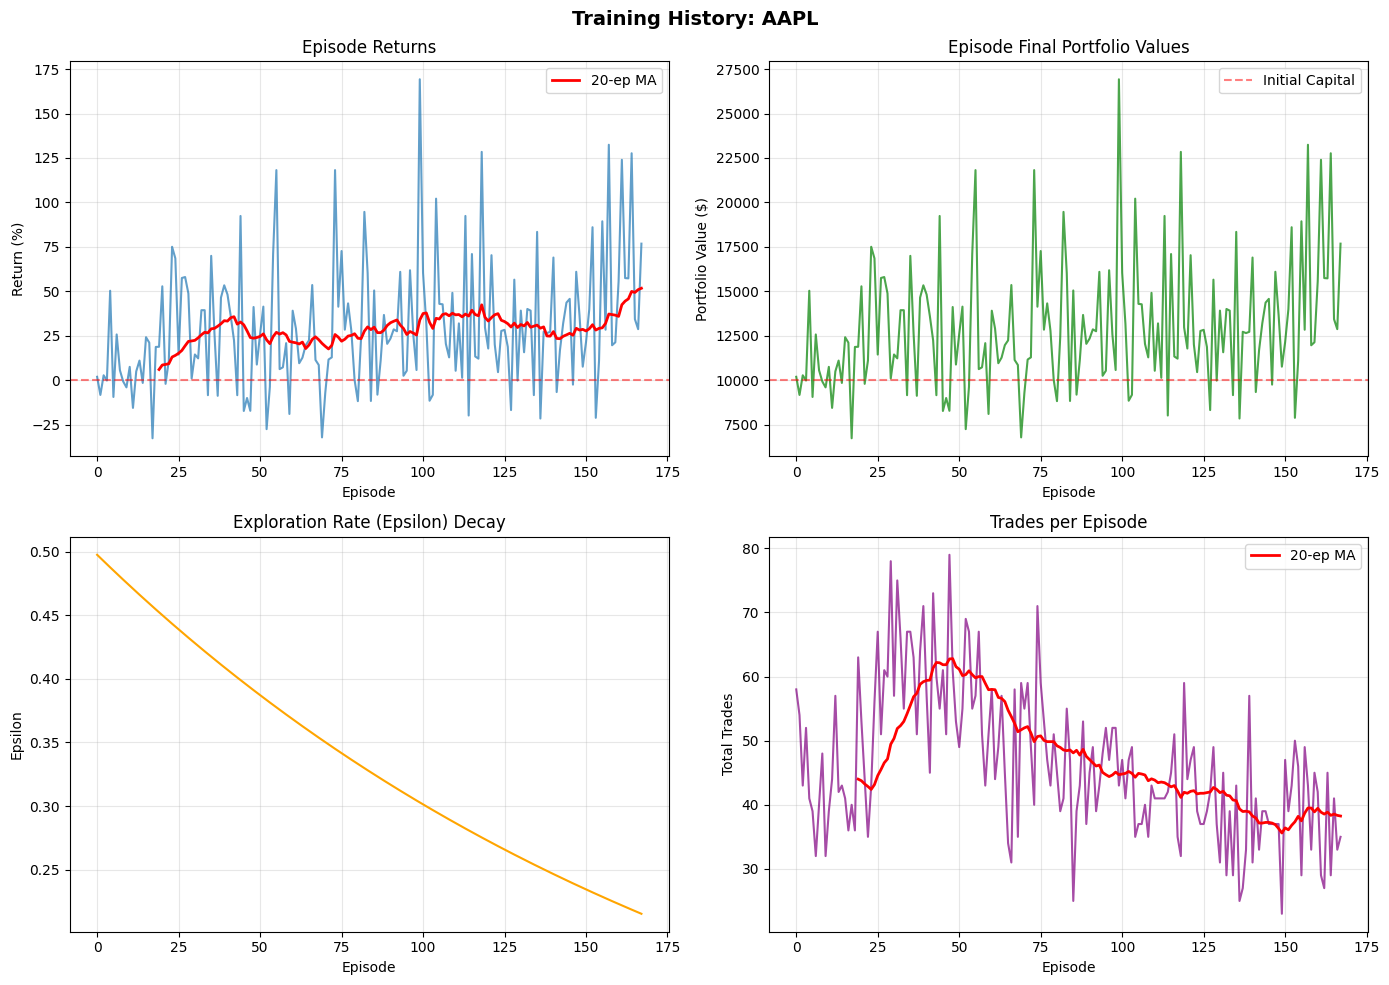


Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,979 (359.30 KB)

 Trainable params: 30,659 (119.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,320 (239.54 KB)

None

TRAINING COMPLETE FOR ALL TICKERS

Trained models saved:
  - double_dqn_models/AAPL_final.keras


In [6]:
# =============================================================================
# MAIN TRAINING PIPELINE - TRAIN ALL TICKERS
# =============================================================================
# Dictionary to store trained agents and their results
trained_agents = {}
training_histories = {}
all_results = []

print("=" * 70)
print("MULTI-TICKER DOUBLE DQN TRAINING PIPELINE")
print("=" * 70)
print(f"\nTickers to train: {tickers}")
print(f"Configuration:")
print(f"  - Window size: {window_size}")
print(f"  - Initial capital: ${initial_capital}")
print(f"  - Episode length: {episode_length}")
print(f"  - Number of passes: {num_passes}")
print(f"  - Transaction cost: {transaction_cost*100}%")
print()

for ticker_idx, ticker in enumerate(tickers):
    print(f"\n{'*'*70}")
    print(f"* TICKER {ticker_idx + 1}/{len(tickers)}: {ticker}")
    print(f"{'*'*70}")
    
    # Load data for this ticker
    train_set, val_set, test_set = load_ticker_data(ticker)
    
    # Train the model
    agent, history, feature_builder = train_ticker(
        ticker=ticker,
        train_set=train_set,
        window_size=window_size,
        initial_capital=initial_capital,
        batch_size=batch_size,
        update_frequency=update_frequency,
        transaction_cost=transaction_cost,
        episode_length=episode_length,
        episode_stride=episode_stride,
        num_passes=num_passes,
        verbose=True  # Set to False for less output
    )
    
    # Store agent and history
    trained_agents[ticker] = agent
    training_histories[ticker] = history
    
    # Plot training history
    plot_training_history(ticker, history)
    
    # Print model summary (only for first ticker)
    if ticker_idx == 0:
        print("\nModel Architecture:")
        print(agent.model.summary())

print("\n" + "=" * 70)
print("TRAINING COMPLETE FOR ALL TICKERS")
print("=" * 70)
print("\nTrained models saved:")
for ticker in tickers:
    print(f"  - double_dqn_models/{ticker}_final.keras")

<a id='6'></a>
# 6. Testing the Data 

After training the data, it is tested it against the test dataset. Our model resulted in a overall profit. The best thing about the model was that the profits kept improving over time, indicating that it was learning well and taking better actions.

In [7]:
# =============================================================================
# VALIDATION/TEST EVALUATION FUNCTION
# =============================================================================
def evaluate_ticker(ticker, agent, eval_set, feature_builder, window_size, 
                    initial_capital, transaction_cost, eval_type="VALIDATION"):
    """
    Evaluate a trained agent on validation or test data.
    
    Args:
        ticker: Stock ticker symbol
        agent: Trained Agent object
        eval_set: Evaluation DataFrame (val or test)
        feature_builder: OHLCVWithIndicators instance
        window_size: Lookback window
        initial_capital: Starting capital
        transaction_cost: Cost per trade (fraction)
        eval_type: "VALIDATION" or "TEST"
        
    Returns:
        results: Dictionary with evaluation metrics
    """
    print("=" * 70)
    print(f"{eval_type} SET EVALUATION: {ticker}")
    print("=" * 70)
 
    # Prepare data
    eval_df = eval_set.copy()
    eval_df = feature_builder.precompute(eval_df)
    eval_data = eval_df['Close'].tolist()
    eval_l = len(eval_data) - 1
 
    # Set agent to evaluation mode
    agent.is_eval = True
    agent.epsilon = 0.0
 
    # Reset portfolio
    agent.reset_portfolio()
 
    # Initialize tracking
    t = window_size
    position = 0.0
    state = getState(eval_df, t, window_size, feature_builder, position)
 
    states_buy = []
    states_sell = []
    trades = []
    total_transaction_costs = 0.0
    buy_entry_cost = 0.0
 
    print(f"\nStarting Capital: {formatPrice(initial_capital)}")
    print(f"{eval_type} Period: {eval_l - window_size} trading days")
    print("-" * 70)
    print(f"{'Action':<8} {'Time':<8} {'Price':<12} {'Shares':<12} {'Trade P/L':<12} {'TxnCost':<10} {'Portfolio':<12}")
    print("-" * 70)
 
    while t < eval_l:
        action = agent.act(state)
        current_price = eval_data[t]
        trade_info = None
 
        if action == 1:  # BUY
            if agent.cash > 0 and agent.shares_held == 0:
                trade_value = agent.cash
                cost = trade_value * transaction_cost
                net_cash = agent.cash - cost
                buy_entry_cost = agent.cash
                agent.shares_held = net_cash / current_price
                agent.cash = 0
                position = 1.0
                total_transaction_costs += cost
                states_buy.append(t)
 
                portfolio_value = agent.get_portfolio_value(current_price)
                trade_info = {
                    'action': 'BUY', 'time': t, 'price': current_price,
                    'shares': agent.shares_held, 'trade_pnl': -cost,
                    'txn_cost': cost, 'portfolio': portfolio_value
                }
                print(f"{'BUY':<8} {t:<8} {formatPrice(current_price):<12} "
                      f"{agent.shares_held:<12.4f} {formatPrice(-cost):<12} "
                      f"{formatPrice(cost):<10} {formatPrice(portfolio_value):<12}")
 
        elif action == 2:  # SELL
            if agent.shares_held > 0:
                gross_sell_value = agent.shares_held * current_price
                cost = gross_sell_value * transaction_cost
                net_sell_value = gross_sell_value - cost
                trade_pnl = net_sell_value - buy_entry_cost
                shares_sold = agent.shares_held
                agent.cash = net_sell_value
                agent.shares_held = 0
                position = 0.0
                total_transaction_costs += cost
                states_sell.append(t)
 
                portfolio_value = agent.get_portfolio_value(current_price)
                trade_info = {
                    'action': 'SELL', 'time': t, 'price': current_price,
                    'shares': shares_sold, 'trade_pnl': trade_pnl,
                    'txn_cost': cost, 'portfolio': portfolio_value
                }
                print(f"{'SELL':<8} {t:<8} {formatPrice(current_price):<12} "
                      f"{shares_sold:<12.4f} {formatPrice(trade_pnl):<12} "
                      f"{formatPrice(cost):<10} {formatPrice(portfolio_value):<12}")
 
        if trade_info:
            trades.append(trade_info)
 
        done = (t == eval_l - 1)
        next_state = getState(eval_df, t + 1, window_size, feature_builder, position) if not done else state
        state = next_state
        t += 1
 
    # LIQUIDATE if still holding
    final_price = eval_data[eval_l - 1]
    if agent.shares_held > 0:
        gross_sell_value = agent.shares_held * final_price
        liquidation_cost = gross_sell_value * transaction_cost
        net_liquidation = gross_sell_value - liquidation_cost
        trade_pnl = net_liquidation - buy_entry_cost
        total_transaction_costs += liquidation_cost
 
        print(f"\n--- LIQUIDATION at end of period ---")
        print(f"{'SELL':<8} {'END':<8} {formatPrice(final_price):<12} "
              f"{agent.shares_held:<12.4f} {formatPrice(trade_pnl):<12} "
              f"{formatPrice(liquidation_cost):<10} {formatPrice(net_liquidation):<12}")
 
        trades.append({
            'action': 'SELL', 'time': eval_l, 'price': final_price,
            'shares': agent.shares_held, 'trade_pnl': trade_pnl,
            'txn_cost': liquidation_cost, 'portfolio': net_liquidation
        })
        states_sell.append(eval_l)
        agent.cash = net_liquidation
        agent.shares_held = 0
 
    # Calculate results
    final_portfolio = agent.cash
    dqn_return = final_portfolio - initial_capital
    dqn_return_pct = (dqn_return / initial_capital) * 100
 
    # Buy and Hold Comparison
    start_price = eval_data[window_size]
    end_price = eval_data[eval_l - 1]
    bh_buy_cost = initial_capital * transaction_cost
    bh_shares = (initial_capital - bh_buy_cost) / start_price
    bh_gross_sell = bh_shares * end_price
    bh_sell_cost = bh_gross_sell * transaction_cost
    bh_final_value = bh_gross_sell - bh_sell_cost
    bh_return = bh_final_value - initial_capital
    bh_return_pct = (bh_return / initial_capital) * 100
    bh_total_costs = bh_buy_cost + bh_sell_cost
 
    # Trade Analysis
    sell_trades = [t for t in trades if t['action'] == 'SELL']
    winning_trades = [t for t in sell_trades if t['trade_pnl'] > 0]
    losing_trades = [t for t in sell_trades if t['trade_pnl'] <= 0]
    total_wins = sum(t['trade_pnl'] for t in winning_trades)
    total_losses = sum(t['trade_pnl'] for t in losing_trades)
 
    # Print Summary
    print("\n" + "=" * 70)
    print(f"{eval_type} SET RESULTS SUMMARY: {ticker}")
    print("=" * 70)
    print(f"\n{'DQN STRATEGY':^35} | {'BUY & HOLD':^35}")
    print("-" * 70)
    print(f"{'Initial Capital:':<20} {formatPrice(initial_capital):<15} | {'Initial Capital:':<20} {formatPrice(initial_capital):<15}")
    print(f"{'Final Portfolio:':<20} {formatPrice(final_portfolio):<15} | {'Final Value:':<20} {formatPrice(bh_final_value):<15}")
    print(f"{'Total Return:':<20} {formatPrice(dqn_return):<15} | {'Total Return:':<20} {formatPrice(bh_return):<15}")
    print(f"{'Return %:':<20} {dqn_return_pct:<14.2f}% | {'Return %:':<20} {bh_return_pct:<14.2f}%")
    print(f"\n{'Total Txn Costs:':<20} {formatPrice(total_transaction_costs):<15} | {'Total Txn Costs:':<20} {formatPrice(bh_total_costs):<15}")
    print(f"{'Total Trades:':<20} {len(trades):<15} | {'Total Trades:':<20} {'2':<15}")
    print(f"{'  - Buys:':<20} {len(states_buy):<15}")
    print(f"{'  - Sells:':<20} {len(states_sell):<15}")
 
    if len(sell_trades) > 0:
        print(f"\n{'TRADE STATISTICS':^70}")
        print("-" * 70)
        print(f"{'Winning Trades:':<25} {len(winning_trades)}")
        print(f"{'Losing Trades:':<25} {len(losing_trades)}")
        win_rate = len(winning_trades) / len(sell_trades) * 100
        print(f"{'Win Rate:':<25} {win_rate:.1f}%")
        print(f"{'Total Profit (wins):':<25} {formatPrice(total_wins)}")
        print(f"{'Total Loss (losses):':<25} {formatPrice(total_losses)}")
        if len(winning_trades) > 0:
            print(f"{'Avg Win:':<25} {formatPrice(total_wins / len(winning_trades))}")
        if len(losing_trades) > 0:
            print(f"{'Avg Loss:':<25} {formatPrice(total_losses / len(losing_trades))}")
 
    print(f"\n{'COST ANALYSIS':^70}")
    print("-" * 70)
    print(f"{'Total Txn Costs:':<25} {formatPrice(total_transaction_costs)}")
    print(f"{'Net Return:':<25} {formatPrice(dqn_return)}")
    print(f"{'Costs as % of Capital:':<25} {(total_transaction_costs/initial_capital)*100:.2f}%")
 
    print("\n" + "-" * 70)
    if dqn_return > bh_return:
        outperformance = dqn_return - bh_return
        print(f"DQN OUTPERFORMED Buy & Hold by {formatPrice(outperformance)} ({(outperformance/initial_capital)*100:.2f}%)")
    else:
        underperformance = bh_return - dqn_return
        print(f"DQN UNDERPERFORMED Buy & Hold by {formatPrice(underperformance)} ({(underperformance/initial_capital)*100:.2f}%)")
    print("=" * 70)
    
    # Plot
    plot_behavior(eval_data, states_buy, states_sell, dqn_return)
    
    # Return results dictionary
    results = {
        'ticker': ticker,
        'eval_type': eval_type,
        'final_portfolio': final_portfolio,
        'dqn_return': dqn_return,
        'dqn_return_pct': dqn_return_pct,
        'bh_return': bh_return,
        'bh_return_pct': bh_return_pct,
        'total_trades': len(trades),
        'num_buys': len(states_buy),
        'num_sells': len(states_sell),
        'total_transaction_costs': total_transaction_costs,
        'outperformance': dqn_return - bh_return,
        'win_rate': len(winning_trades) / len(sell_trades) * 100 if len(sell_trades) > 0 else 0
    }
    
    return results

EVALUATION PIPELINE - ALL TICKERS

**********************************************************************
* EVALUATING: AAPL
**********************************************************************
VALIDATION SET EVALUATION: AAPL

Starting Capital: $10000.00
VALIDATION Period: 384 trading days
----------------------------------------------------------------------
Action   Time     Price        Shares       Trade P/L    TxnCost    Portfolio   
----------------------------------------------------------------------
BUY      30       $144.71      69.0367      -$10.00      $10.00     $9990.00    
SELL     40       $136.20      69.0367      -$606.88     $9.40      $9393.12    
BUY      47       $147.67      63.5444      -$9.39       $9.39      $9383.73    
SELL     62       $138.72      63.5444      -$587.33     $8.81      $8805.79    
BUY      65       $142.21      61.8593      -$8.81       $8.81      $8796.98    
SELL     72       $133.31      61.8593      -$567.44     $8.25      $8238.35   

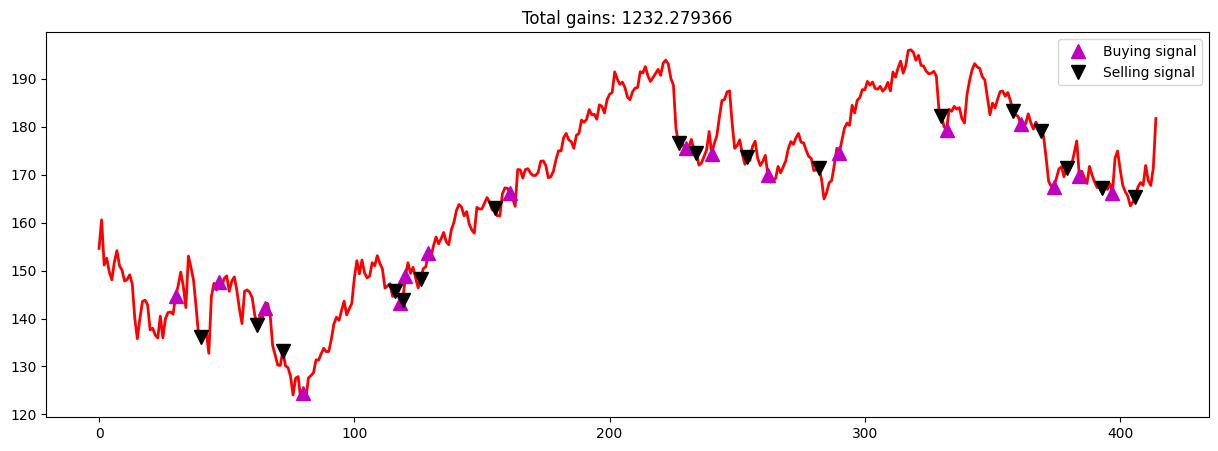

TEST SET EVALUATION: AAPL

Starting Capital: $10000.00
TEST Period: 384 trading days
----------------------------------------------------------------------
Action   Time     Price        Shares       Trade P/L    TxnCost    Portfolio   
----------------------------------------------------------------------
BUY      30       $212.65      46.9796      -$10.00      $10.00     $9990.00    
SELL     53       $223.28      46.9796      $479.27      $10.49     $10479.27   
BUY      60       $216.68      48.3136      -$10.48      $10.48     $10468.79   
SELL     83       $219.41      48.3136      $110.55      $10.60     $10589.82   
BUY      94       $227.38      46.5274      -$10.59      $10.59     $10579.23   
SELL     105      $225.32      46.5274      -$116.76     $10.48     $10473.06   
BUY      130      $225.73      46.3507      -$10.47      $10.47     $10462.59   
SELL     170      $241.38      46.3507      $703.93      $11.19     $11177.00   
BUY      172      $233.13      47.8960      

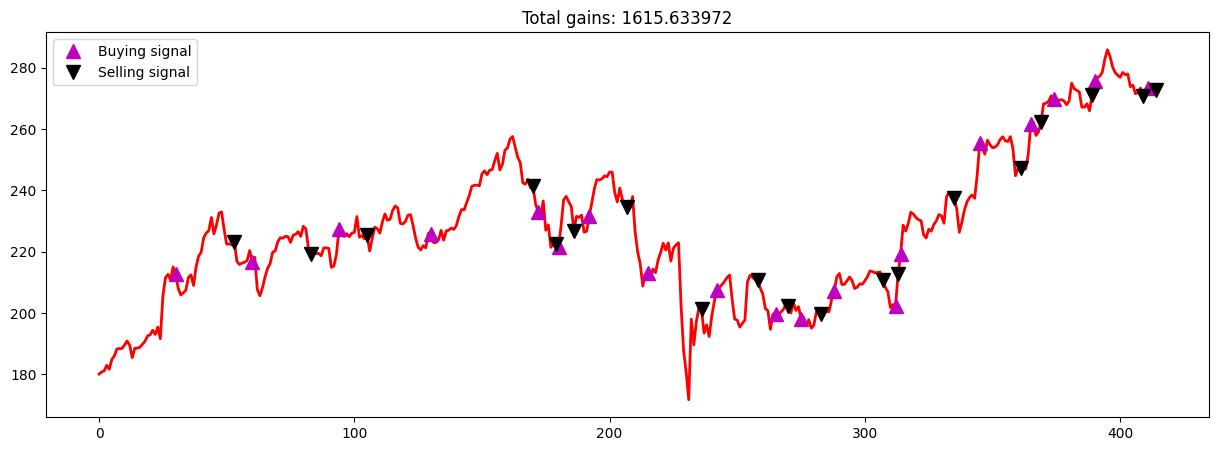


FINAL SUMMARY - ALL TICKERS

------------------------------------------------------------------------------------------
VALIDATION SET RESULTS
------------------------------------------------------------------------------------------
Ticker   DQN Return%  B&H Return%  Outperform%  Win Rate%  Trades  
------------------------------------------------------------------------------------------
AAPL     12.32        18.26        -5.94        47.1       34      

------------------------------------------------------------------------------------------
TEST SET RESULTS
------------------------------------------------------------------------------------------
Ticker   DQN Return%  B&H Return%  Outperform%  Win Rate%  Trades  
------------------------------------------------------------------------------------------
AAPL     16.16        28.36        -12.21       68.4       38      

------------------------------------------------------------------------------------------
AVERAGE PERFORMANCE

In [8]:
# =============================================================================
# EVALUATE ALL TICKERS ON VALIDATION AND TEST SETS
# =============================================================================
validation_results = []
test_results = []

print("=" * 70)
print("EVALUATION PIPELINE - ALL TICKERS")
print("=" * 70)

for ticker in tickers:
    print(f"\n{'*'*70}")
    print(f"* EVALUATING: {ticker}")
    print(f"{'*'*70}")
    
    # Load data for this ticker
    train_set, val_set, test_set = load_ticker_data(ticker)
    
    # Get the trained agent for this ticker
    agent = trained_agents[ticker]
    
    # Recreate feature builder (needed for evaluation)
    feature_builder = OHLCVWithIndicators(window_size=window_size)
    
    # Evaluate on validation set
    val_result = evaluate_ticker(
        ticker=ticker,
        agent=agent,
        eval_set=val_set,
        feature_builder=feature_builder,
        window_size=window_size,
        initial_capital=initial_capital,
        transaction_cost=transaction_cost,
        eval_type="VALIDATION"
    )
    validation_results.append(val_result)
    
    # Evaluate on test set
    test_result = evaluate_ticker(
        ticker=ticker,
        agent=agent,
        eval_set=test_set,
        feature_builder=feature_builder,
        window_size=window_size,
        initial_capital=initial_capital,
        transaction_cost=transaction_cost,
        eval_type="TEST"
    )
    test_results.append(test_result)

# =============================================================================
# SUMMARY TABLE FOR ALL TICKERS
# =============================================================================
print("\n" + "=" * 90)
print("FINAL SUMMARY - ALL TICKERS")
print("=" * 90)

# Validation Summary
print("\n" + "-" * 90)
print("VALIDATION SET RESULTS")
print("-" * 90)
print(f"{'Ticker':<8} {'DQN Return%':<12} {'B&H Return%':<12} {'Outperform%':<12} {'Win Rate%':<10} {'Trades':<8}")
print("-" * 90)
for r in validation_results:
    outperf = r['dqn_return_pct'] - r['bh_return_pct']
    print(f"{r['ticker']:<8} {r['dqn_return_pct']:<12.2f} {r['bh_return_pct']:<12.2f} {outperf:<12.2f} {r['win_rate']:<10.1f} {r['total_trades']:<8}")

# Test Summary
print("\n" + "-" * 90)
print("TEST SET RESULTS")
print("-" * 90)
print(f"{'Ticker':<8} {'DQN Return%':<12} {'B&H Return%':<12} {'Outperform%':<12} {'Win Rate%':<10} {'Trades':<8}")
print("-" * 90)
for r in test_results:
    outperf = r['dqn_return_pct'] - r['bh_return_pct']
    print(f"{r['ticker']:<8} {r['dqn_return_pct']:<12.2f} {r['bh_return_pct']:<12.2f} {outperf:<12.2f} {r['win_rate']:<10.1f} {r['total_trades']:<8}")

# Average performance
print("\n" + "-" * 90)
print("AVERAGE PERFORMANCE")
print("-" * 90)
avg_val_dqn = sum(r['dqn_return_pct'] for r in validation_results) / len(validation_results)
avg_val_bh = sum(r['bh_return_pct'] for r in validation_results) / len(validation_results)
avg_test_dqn = sum(r['dqn_return_pct'] for r in test_results) / len(test_results)
avg_test_bh = sum(r['bh_return_pct'] for r in test_results) / len(test_results)

print(f"Validation - DQN Avg: {avg_val_dqn:.2f}%, B&H Avg: {avg_val_bh:.2f}%, Outperformance: {avg_val_dqn - avg_val_bh:.2f}%")
print(f"Test       - DQN Avg: {avg_test_dqn:.2f}%, B&H Avg: {avg_test_bh:.2f}%, Outperformance: {avg_test_dqn - avg_test_bh:.2f}%")

print("\n" + "=" * 90)
print("EVALUATION COMPLETE")
print("=" * 90)

In [9]:
# =============================================================================
# UTILITY: LOAD AND EVALUATE A SAVED MODEL
# =============================================================================
def load_and_evaluate_ticker(ticker, model_path=None, eval_type="both"):
    """
    Load a saved model and evaluate it on validation and/or test data.
    
    Args:
        ticker: Stock ticker symbol (e.g., 'AAPL')
        model_path: Path to saved model. If None, uses 'models/{ticker}_final.keras'
        eval_type: "validation", "test", or "both"
        
    Returns:
        results: Dictionary with evaluation results
    """
    if model_path is None:
        model_path = f"double_dqn_models/{ticker}_final.keras"
    
    print(f"\nLoading model from: {model_path}")
    
    # Create agent in evaluation mode with the saved model
    feature_builder = OHLCVWithIndicators(window_size=window_size)
    state_size = feature_builder.obs_dim
    agent = Agent(state_size, initial_capital=initial_capital, is_eval=True, model_name=model_path)
    
    # Load ticker data
    train_set, val_set, test_set = load_ticker_data(ticker)
    
    results = {}
    
    if eval_type in ["validation", "both"]:
        val_result = evaluate_ticker(
            ticker=ticker,
            agent=agent,
            eval_set=val_set,
            feature_builder=feature_builder,
            window_size=window_size,
            initial_capital=initial_capital,
            transaction_cost=transaction_cost,
            eval_type="VALIDATION"
        )
        results['validation'] = val_result
    
    if eval_type in ["test", "both"]:
        # Need to recreate agent/feature builder since evaluate_ticker modifies them
        feature_builder = OHLCVWithIndicators(window_size=window_size)
        agent = Agent(state_size, initial_capital=initial_capital, is_eval=True, model_name=model_path)
        
        test_result = evaluate_ticker(
            ticker=ticker,
            agent=agent,
            eval_set=test_set,
            feature_builder=feature_builder,
            window_size=window_size,
            initial_capital=initial_capital,
            transaction_cost=transaction_cost,
            eval_type="TEST"
        )
        results['test'] = test_result
    
    return results


# Example usage (uncomment to run):
# results = load_and_evaluate_ticker('AAPL')
# results = load_and_evaluate_ticker('MSFT', model_path='double_dqn_models/MSFT_pass2.keras', eval_type='test')

print("\n" + "=" * 70)
print("UTILITY FUNCTION LOADED: load_and_evaluate_ticker()")
print("=" * 70)
print("""
Usage examples:
  # Evaluate AAPL with final model on both val and test
  results = load_and_evaluate_ticker('AAPL')
  
  # Evaluate MSFT with a specific pass model on test only
  results = load_and_evaluate_ticker('MSFT', model_path='double_dqn_models/MSFT_pass1.keras', eval_type='test')
  
  # Evaluate GOOGL on validation only
  results = load_and_evaluate_ticker('GOOGL', eval_type='validation')
""")


UTILITY FUNCTION LOADED: load_and_evaluate_ticker()

Usage examples:
  # Evaluate AAPL with final model on both val and test
  results = load_and_evaluate_ticker('AAPL')

  # Evaluate MSFT with a specific pass model on test only
  results = load_and_evaluate_ticker('MSFT', model_path='double_dqn_models/MSFT_pass1.keras', eval_type='test')

  # Evaluate GOOGL on validation only
  results = load_and_evaluate_ticker('GOOGL', eval_type='validation')

